### [Smart Money Concepts (SMC) - Backtesting Algo-Trading Strategies with EODHD Data](https://wire.insiderfinance.io/the-smc-edge-with-eodhd-why-swings-win-over-fvg-e1e974176972)

> The SMC Edge with EODHD

#### Swing Highs and Lows
- A *swing high* is when the current high is the highest high out of the `swing_length` amount of candles before and after.
- A *swing low* is when the current low is the lowest low out of the `swing_length` amount of candles before and after.

In [1]:
# 1. Upgrade build tools
!pip install -qq --no-deps --upgrade pip setuptools wheel

# 2. Install core dependencies first (precompiled wheels)
!pip install -qq --no-deps numpy pandas scipy ta TA-Lib

# 3. Then install the package
!pip install -qq --no-deps smartmoneyconcepts --only-binary=:all:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd

from smartmoneyconcepts.smc import smc

import yfinance as yf
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

%autosave 10

Autosaving every 10 seconds


In [3]:
df = yf.download('AAPL', start='2025-01-01', end='2025-12-31', interval='1d', progress=False, multi_level_index=False)
df.rename(columns=str.lower, inplace=True)
#df.index = pd.to_datetime(df.index)

display(df.tail(20))

,close,high,low,open,volume
Date,,,,,
2025-12-02,285.9225,287.1313,282.3658,282.7354,53669500
2025-12-03,283.8844,288.3502,283.0352,285.9325,43538700
2025-12-04,280.4376,284.4638,278.3295,283.8344,43989100
2025-12-05,278.5194,280.8772,277.7901,280.2777,47265800
2025-12-08,277.6302,279.4086,275.8918,277.8700,38211800
2025-12-09,276.9209,279.7682,276.6611,277.9000,32193300
2025-12-10,278.5194,279.4885,276.1816,277.4903,33038300
2025-12-11,277.7701,279.3286,273.5540,278.8391,33248000
2025-12-12,278.0199,278.9590,276.5612,277.6402,39532900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2025-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   249 non-null    float64
 1   high    249 non-null    float64
 2   low     249 non-null    float64
 3   open    249 non-null    float64
 4   volume  249 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [5]:
# Create subplots and mention plot grid size
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
               vertical_spacing=0.03, subplot_titles=('OHLC AAPL.US', 'Volume'),
               row_width=[0.2, 0.7])

# Plot OHLC on 1st row
fig.add_trace(go.Candlestick(x=df.index, open=df["open"], high=df["high"],
  low=df["low"], close=df["close"], name="OHLC"),
  row=1, col=1
)

# Bar trace for volumes on 2nd row without legend
fig.add_trace(go.Bar(x=df.index, y=df['volume'], showlegend=False), row=2, col=1)

# Do not show OHLC's rangeslider plot
fig.update(layout_xaxis_rangeslider_visible=False)
fig.show()

In [6]:
df_ind = df.copy()
df_ind.index = pd.to_datetime(df_ind.index)
ohlc = df.copy()

In [7]:
myfvg = smc.fvg(ohlc)
print(myfvg.columns)

Index(['FVG', 'Top', 'Bottom', 'MitigatedIndex'], dtype='object')


In [8]:
df = pd.DataFrame(index=(ohlc.index))
mylist = myfvg["FVG"]
se = pd.Series(mylist)
df['FVG'] = se.values

In [9]:
bullsignals = ohlc['close'][df["FVG"] == 1]
bearsignals = ohlc['close'][df["FVG"] == -1]

print(f"{len(bullsignals)} bull signals")
print(f"{len(bearsignals)} bear signals")

32 bull signals
29 bear signals


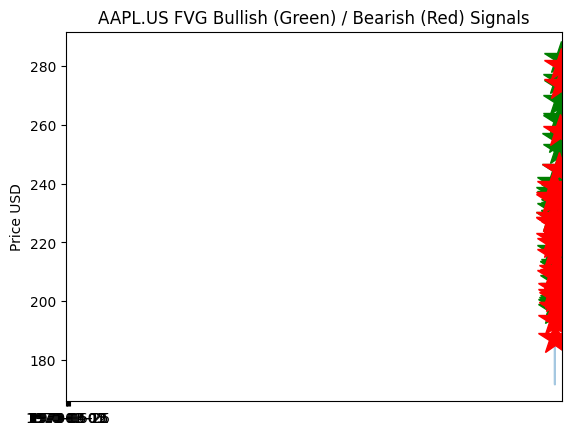

In [10]:
plt.plot(ohlc['close'], alpha=0.4)
for idx in bullsignals.index:
  plt.plot(
    idx,
    ohlc.loc[idx]["close"],
    "g*",
    markersize=25
  )

for idx in bearsignals.index:
  plt.plot(
    idx,
    ohlc.loc[idx]["close"],
    "r*",
    markersize=25
  )
plt.xticks([])



plt.title('AAPL.US FVG Bullish (Green) / Bearish (Red) Signals')
plt.ylabel('Price USD')
listOf_Xticks = np.arange(0, 192, 35)
plt.xticks(listOf_Xticks)
plt.show()

In [11]:
position = []

df["FVG"]=df["FVG"].shift(1)
for i in range(len(ohlc['close'])):
  position.append(0)

for i in range(len(ohlc['close'])):
  if df["FVG"][i] == 1:
    position[i] = 1
  elif df["FVG"][i] == -1:
    position[i] = 0
  else:
    position[i] = position[i-1]

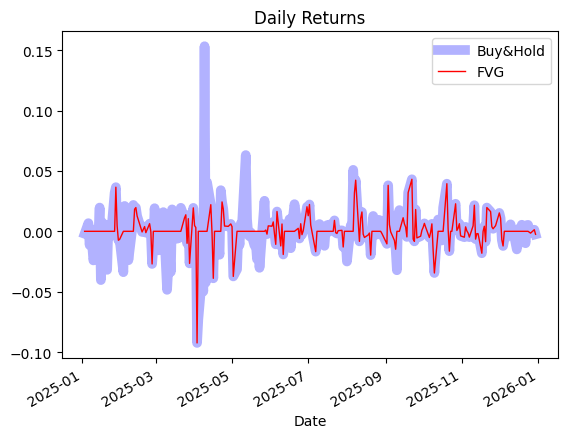

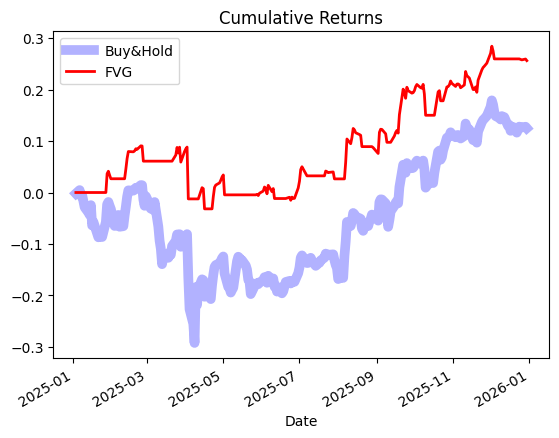

In [12]:
rets = ohlc.close.pct_change()[1:]
strat_rets = position[1:] * rets

plt.title('Daily Returns')
rets.plot(color = 'blue', alpha = 0.3, linewidth = 7,label='Buy&Hold')
strat_rets.plot(color = 'r', linewidth = 1,label='FVG')
plt.legend()
plt.show()
rets_cum = (1 + rets).cumprod() - 1
strat_cum = (1 + strat_rets).cumprod() - 1
plt.title('Cumulative Returns')
rets_cum.plot(color = 'blue', alpha = 0.3, linewidth = 7,label='Buy&Hold')
strat_cum.plot(color = 'r', linewidth = 2,label='FVG')
plt.legend()
plt.show()

In [13]:
myswing = smc.swing_highs_lows(ohlc, swing_length = 5)
print(myswing.columns)

Index(['HighLow', 'Level'], dtype='object')


In [14]:
dfs = pd.DataFrame(index=(ohlc.index))
mylist = myswing["HighLow"]
se = pd.Series(mylist)
dfs['HighLow'] = se.values

In [15]:
highsignals = ohlc['close'][dfs["HighLow"] == 1]
lowsignals = ohlc['close'][dfs["HighLow"] == -1]

print(f"{len(highsignals)} high signals")
print(f"{len(lowsignals)} low signals")

17 high signals
16 low signals


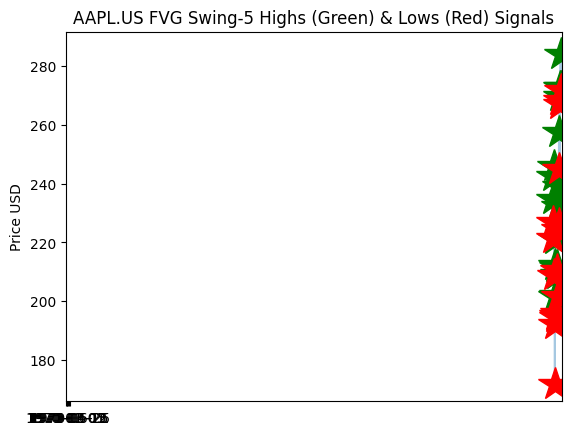

In [16]:
plt.plot(ohlc['close'], alpha=0.4)
for idx in highsignals.index.tolist():
  plt.plot(
    idx,
    ohlc.loc[idx]["close"],
    "g*",
    markersize=25
  )

for idx in lowsignals.index.tolist():
  plt.plot(
    idx,
    ohlc.loc[idx]["close"],
    "r*",
    markersize=25
  )
plt.xticks([])

plt.title('AAPL.US FVG Swing-5 Highs (Green) & Lows (Red) Signals')
plt.ylabel('Price USD')
listOf_Xticks = np.arange(0, 192, 35)
plt.xticks(listOf_Xticks)

plt.show()

In [17]:
dfs["HighLow"] = dfs["HighLow"].shift(1)

position = []

for i in range(len(ohlc['close'])):
  position.append(0)


for i in range(len(ohlc['close'])):
  if dfs["HighLow"][i] == -1:
    position[i] = 1
  elif dfs["HighLow"][i] == 1:
    position[i] = 0
  else:
    position[i] = position[i-1]

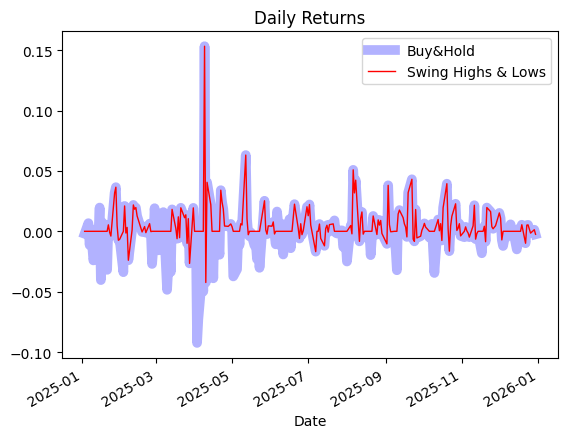

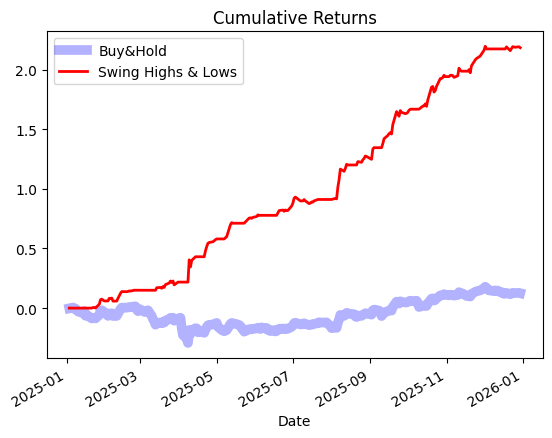

In [18]:
rets = ohlc.close.pct_change()[1:]
strat_rets = position[1:] * rets

plt.title('Daily Returns')
rets.plot(color = 'blue', alpha = 0.3, linewidth = 7,label='Buy&Hold')
strat_rets.plot(color = 'r', linewidth = 1,label='Swing Highs & Lows')
plt.legend()
plt.show()

rets_cum = (1 + rets).cumprod() - 1
strat_cum = (1 + strat_rets).cumprod() - 1

plt.title('Cumulative Returns')
rets_cum.plot(color = 'blue', alpha = 0.3, linewidth = 7,label='Buy&Hold')
strat_cum.plot(color = 'r', linewidth = 2,label='Swing Highs & Lows')
plt.legend()
plt.show()